<a href="https://colab.research.google.com/github/PriyanshuJVM/7th-sem-final-project/blob/main/CNN%20Models/CNN%20Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor Detection using CNN

This notebook provides a complete workflow for training a Convolutional Neural Network (CNN) to detect brain tumors from MRI images. The steps include:

1.  **Environment Setup**: Installing necessary libraries like Kaggle API client.
2.  **Kaggle API Setup**: Uploading your `kaggle.json` for authentication.
3.  **Data Download**: Fetching the `masoudnickparvar/brain-tumor-mri-dataset` from Kaggle.
4.  **Data Preprocessing**: Loading, augmenting, and preparing images using `ImageDataGenerator`.
5.  **Model Definition**: Designing a CNN architecture.
6.  **Model Training**: Compiling and training the model.
7.  **Model Evaluation**: Assessing the model's performance on the test set.
8.  **Prediction & Visualization**: Demonstrating predictions on new images.

## 1. Environment Setup

In [25]:
# Install the Kaggle API client
!pip install -q kaggle

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## 2. Kaggle API Setup

To download datasets from Kaggle, you need to provide your API credentials. Follow these steps:

1.  Go to your Kaggle account settings.
2.  Under the 'API' section, click 'Create New API Token' to download `kaggle.json`.
3.  Upload the `kaggle.json` file when prompted by the `files.upload()` widget below.

This will configure your Kaggle API key in the Colab environment.

In [26]:
from google.colab import files

print("Please upload your kaggle.json file:")
files.upload()

# Move kaggle.json to the correct directory and set permissions
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key uploaded and configured successfully.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle API key uploaded and configured successfully.


## 3. Download and Extract Brain Tumor Dataset

We will download the `masoudnickparvar/brain-tumor-mri-dataset` dataset from Kaggle. This dataset contains MRI images categorized into four classes: 'glioma', 'meningioma', 'notumor', and 'pituitary'.

In [27]:
# Define the Kaggle dataset identifier
KAGGLE_DATASET = "masoudnickparvar/brain-tumor-mri-dataset"

# Create a directory for the dataset and navigate into it
!mkdir -p brain_tumor_dataset
%cd brain_tumor_dataset

# Download the dataset
print(f"Downloading dataset: {KAGGLE_DATASET}...")
!kaggle datasets download -d {KAGGLE_DATASET}

# Unzip the downloaded file(s) and remove the zip files
print("Unzipping dataset...")
!unzip -q \*.zip && rm \*.zip

# Navigate back to the parent directory
%cd ..

print("Dataset downloaded and extracted to 'brain_tumor_dataset/'.")
print("Dataset structure after extraction:")
!ls -R brain_tumor_dataset

/content/brain_tumor_dataset
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Unzipping dataset...
replace Testing/glioma/Te-gl_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Testing/glioma/Te-gl_10.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace Testing/glioma/Te-gl_10.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
rm: cannot remove '*.zip': No such file or directory
/content
Dataset downloaded and extracted to 'brain_tumor_dataset/'.
Dataset structure after extraction:
brain_tumor_dataset:
brain-tumor-mri-dataset.zip  Testing  Training

brain_tumor_dataset/Testing:
glioma	meningioma  notumor  pituitary

brain_tumor_dataset/Testing/glioma:
Te-gl_100.jpg  Te-gl_173.jpg  Te-gl_245.jpg  Te-gl_317.jpg  Te-gl_38.jpg
Te-gl_101.jpg  Te-gl_174.jpg  Te-gl_

## 4. Data Preprocessing

We'll use `ImageDataGenerator` to efficiently load images, apply data augmentation (rescaling, rotation, shifting, zooming, flipping) to the training set to prevent overfitting, and convert images into batches for the model. The dataset is structured into `Training` and `Testing` subdirectories, with class-specific folders inside.

In [ ]:
# Define paths to the dataset
DATASET_DIR = 'brain_tumor_dataset'
TRAIN_DIR = os.path.join(DATASET_DIR, 'Training')
TEST_DIR = os.path.join(DATASET_DIR, 'Testing')

# Image parameters
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
NUM_CLASSES = 4 # Based on the dataset: glioma, meningioma, notumor, pituitary

# Create ImageDataGenerator for data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255) # Only rescale for test data, no augmentation

# Load images using flow_from_directory
print("Creating training data generator...")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

print("Creating testing data generator...")
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Do not shuffle test data to maintain order for evaluation
)

print("\nImage generators created. Example batch from training set:")
# Get one batch of images and labels to verify
images, labels = next(train_generator)

# Print shapes to verify
print(f"Batch Image Shape: {images.shape}") # (batch_size, IMG_HEIGHT, IMG_WIDTH, 3)
print(f"Batch Labels Shape: {labels.shape}") # (batch_size, num_classes)

# Display a few images from the batch
class_names = list(train_generator.class_indices.keys())
print(f"Class Names: {class_names}")

plt.figure(figsize=(10, 10))
for i in range(min(9, BATCH_SIZE)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    # Get the class name for the current image
    predicted_class_index = np.argmax(labels[i])
    plt.title(class_names[predicted_class_index])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Model Definition

We will define a Convolutional Neural Network (CNN) using Keras Sequential API. The model will consist of multiple convolutional layers followed by max-pooling layers for feature extraction, and then fully connected layers for classification. Dropout layers will be added to reduce overfitting.

In [29]:
def create_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Define the input shape for the model
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# Create the model
model = create_cnn_model(input_shape, NUM_CLASSES)

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,035,716 (72.62 MB)

 Trainable params: 19,035,716 (72.62 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Model Training

Now, we will compile and train the CNN model. We'll use the Adam optimizer and `categorical_crossentropy` loss since this is a multi-class classification problem. `EarlyStopping` will be used to stop training if validation loss doesn't improve, and `ModelCheckpoint` to save the best model.

In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
# EarlyStopping: Stop training when a monitored quantity has stopped improving.
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ModelCheckpoint: Save the model after every epoch if it is the best one seen so far.
model_checkpoint = ModelCheckpoint(
    'best_brain_tumor_model.h5', # File path to save the model
    monitor='val_accuracy',      # Quantity to monitor
    save_best_only=True,         # Only save when `val_accuracy` improves
    mode='max',                  # The greater the `val_accuracy`, the better
    verbose=1
)

# Train the model
print("\nStarting model training...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=50, # Set a reasonably high number, EarlyStopping will manage it
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, model_checkpoint]
)

print("\nModel training finished.")


Starting model training...
Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4118 - loss: 1.2147
Epoch 1: val_accuracy improved from None to 0.50063, saving model to best_brain_tumor_model.h5



Epoch 1: finished saving model to best_brain_tumor_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.4945 - loss: 1.0913 - val_accuracy: 0.5006 - val_loss: 1.5993
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6307 - loss: 0.8763
Epoch 2: val_accuracy improved from 0.50063 to 0.54000, saving model to best_brain_tumor_model.h5



Epoch 2: finished saving model to best_brain_tumor_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 386s 2s/step - accuracy: 0.6482 - loss: 0.8391 - val_accuracy: 0.5400 - val_loss: 1.7047
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6897 - loss: 0.7544
Epoch 3: val_accuracy did not improve from 0.54000
175/175 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.7009 - loss: 0.7180 - val_accuracy: 0.4969 - val_loss: 1.9330
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7148 - loss: 0.6923
Epoch 4: val_accuracy did not improve from 0.54000
175/175 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.7314 - loss: 0.6575 - val_accuracy: 0.5400 - val_loss: 1.8115
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7542 - loss: 0.6050
Epoch 5: val_accuracy improved from 0.54000 to 0.70250, saving model to best_brain_tumor_model.h5



Epoch 5: finished saving model to best_brain_tumor_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.7682 - loss: 0.5864 - val_accuracy: 0.7025 - val_loss: 1.0837
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7834 - loss: 0.5564
Epoch 6: val_accuracy improved from 0.70250 to 0.74313, saving model to best_brain_tumor_model.h5



Epoch 6: finished saving model to best_brain_tumor_model.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.7757 - loss: 0.5620 - val_accuracy: 0.7431 - val_loss: 1.0034
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7856 - loss: 0.5506
Epoch 7: val_accuracy did not improve from 0.74313
175/175 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.7937 - loss: 0.5255 - val_accuracy: 0.7256 - val_loss: 1.1335
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8116 - loss: 0.4890
Epoch 8: val_accuracy did not improve from 0.74313
175/175 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.8111 - loss: 0.4854 - val_accuracy: 0.7269 - val_loss: 1.0952
Epoch 9/50
 35/175 ━━━━━━━━━━━━━━━━━━━━ 4:05 2s/step - accuracy: 0.8203 - loss: 0.4425

## 7. Model Evaluation

After training, we evaluate the model's performance on the unseen test dataset. We'll look at overall accuracy, loss, and a detailed classification report including precision, recall, and F1-score for each class, as well as a confusion matrix.

In [ ]:
# Evaluate the model on the test data
print("\nEvaluating model on test data...")
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get predictions for the test set
Y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true_classes = test_generator.classes[test_generator.index_array]

# Get class labels from the generator
class_labels = list(test_generator.class_indices.keys())

# Display classification report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_labels))

# Display confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 8. Prediction & Visualization

Finally, let's visualize some predictions from the trained model on a few test images to see how it performs qualitatively.

In [ ]:
# Get a batch of test images and labels
# Ensure test_generator is reset to get images from the beginning
test_generator.reset()
images, true_labels = next(test_generator)

# Make predictions
predictions = model.predict(images)
predicted_labels = np.argmax(predictions, axis=1)
true_label_indices = np.argmax(true_labels, axis=1)

# Display some test images with their true and predicted labels
plt.figure(figsize=(15, 15))
for i in range(min(9, BATCH_SIZE)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    true_class = class_labels[true_label_indices[i]]
    predicted_class = class_labels[predicted_labels[i]]

    color = "green" if true_class == predicted_class else "red"
    plt.title(f"True: {true_class}\nPred: {predicted_class}", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

print("\nPrediction visualization complete.")

In [2]:
import requests
import pandas as pd

# Define the API endpoint (using a public JSONPlaceholder API as an example)
api_url = "https://jsonplaceholder.typicode.com/posts"

# Make a GET request to the API
response = requests.get(api_url)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the JSON response
    data = response.json()

    # Convert the data to a pandas DataFrame for easier viewing
    df = pd.DataFrame(data)

    # Display the first 5 rows of the DataFrame
    print("Data fetched successfully:")
    display(df.head())
else:
    print(f"Failed to fetch data. Status code: {response.status_code}")
    print(f"Response: {response.text}")

Data fetched successfully:


,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...


In [8]:
%cd /content/gdrive/My Drive/Multiple
!ls

[Errno 2] No such file or directory: '/content/gdrive/My Drive/Multiple'
/content
sample_data


## Setup Kaggle API

First, we need to install the Kaggle API client. Then, you'll need to upload your `kaggle.json` file containing your API credentials. To do this, download your `kaggle.json` file from your Kaggle account (go to your profile, then Account, and click 'Create New API Token'). Once downloaded, upload it to your Colab environment in the next step. You will see a file upload widget.

In [9]:
# Install the Kaggle API client
!pip install -q kaggle

In [10]:
# Upload your Kaggle API key (kaggle.json)
from google.colab import files

print("Please upload your kaggle.json file:")
files.upload()

# Move kaggle.json to the correct directory
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key uploaded and configured.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle API key uploaded and configured.


## Download and Extract Brain Tumor Dataset

I will use the `sartajbhuvaji/brain-tumor-classification-dataset` from Kaggle. If you wish to use a different dataset, please provide its Kaggle identifier (e.g., `user/dataset-name`).

In [13]:
# Define the Kaggle dataset identifier
KAGGLE_DATASET = "masoudnickparvar/brain-tumor-mri-dataset"

# Create a directory for the dataset
!mkdir -p brain_tumor_dataset
%cd brain_tumor_dataset

# Download the dataset
!kaggle datasets download -d {KAGGLE_DATASET}

# Unzip the downloaded file
!unzip \*.zip && rm \*.zip

%cd ..
print("Dataset downloaded and extracted to 'brain_tumor_dataset/'.")

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  inflating: Training/glioma/Tr-gl_298.jpg  
  inflating: Training/glioma/Tr-gl_299.jpg  
  inflating: Training/glioma/Tr-gl_3.jpg  
  infla

## Load and Preprocess Images

Now, let's load the images and prepare them for a model. This example assumes a common directory structure where images are categorized into subfolders (e.g., `Testing/glioma_tumor`, `Training/meningioma_tumor`). We'll use `tensorflow.keras.preprocessing.image.ImageDataGenerator` for efficient loading and augmentation.

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Image generators created. Example batch:
Batch Image Shape: (32, 150, 150, 3)
Batch Labels Shape: (32, 4)


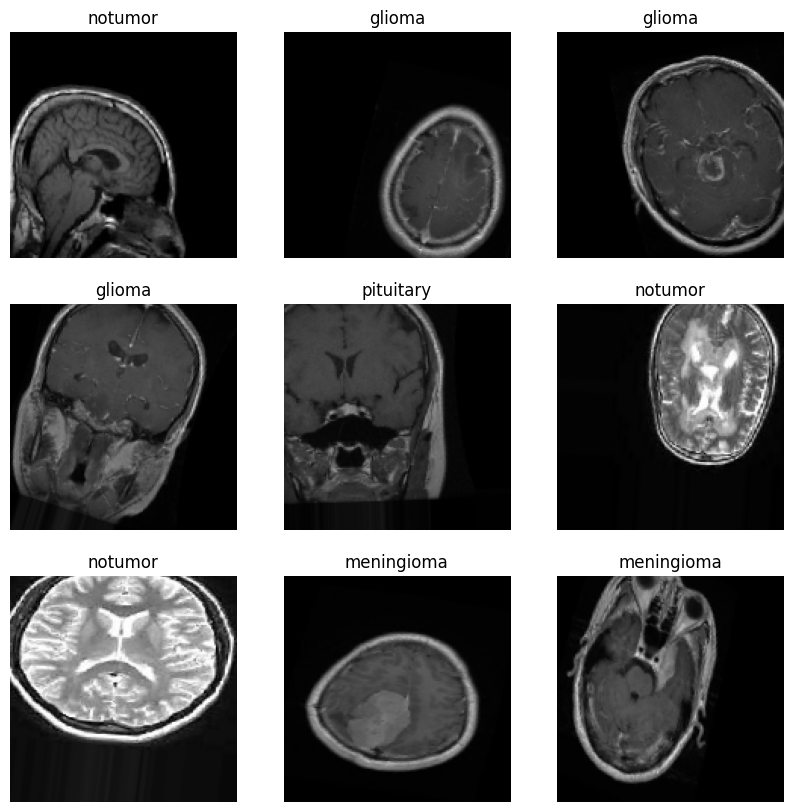

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import os

# Define paths to the dataset
DATASET_DIR = 'brain_tumor_dataset' # Corrected path
TRAIN_DIR = os.path.join(DATASET_DIR, 'Training')
TEST_DIR = os.path.join(DATASET_DIR, 'Testing')

# Image parameters
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Create ImageDataGenerator for data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load images using flow_from_directory
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("Image generators created. Example batch:")
# Get one batch of images and labels
images, labels = next(train_generator)

# Print shapes to verify
print(f"Batch Image Shape: {images.shape}") # (batch_size, IMG_HEIGHT, IMG_WIDTH, 3)
print(f"Batch Labels Shape: {labels.shape}") # (batch_size, num_classes)

# Display a few images from the batch
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")
plt.show()

In [19]:
# %tensorflow_version 1.x # This line is unsupported in Colab and should be removed or commented out.

In [24]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
import pickle
import time
import numpy as np
import keras.optimizers
from sklearn.metrics import classification_report

In [22]:
import tensorflow
print(tensorflow.__version__)

2.20.0


In [ ]:
tensorboard = TensorBoard(log_dir='./logs', histogram_freq=0,
                          write_graph=True, write_images=False)
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)


In [ ]:
import pickle

pickle_in = open("X_test.pickle","rb")
X_test = pickle.load(pickle_in)

pickle_in = open("X_train.pickle","rb")
X_train = pickle.load(pickle_in)

pickle_in = open("Y_test.pickle","rb")
Y_test = pickle.load(pickle_in)

pickle_in = open("Y_train.pickle","rb")
Y_train = pickle.load(pickle_in)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(1006, 150, 150, 3)
(607, 150, 150, 3)


In [ ]:
dense_layers = [0,1,2]
layer_sizes = [32, 64, 128]
conv_layers = [1, 2, 3]

for dense_layer in dense_layers:
    for layer_size in layer_sizes:
        for conv_layer in conv_layers:
            NAME = "{}-conv-{}-nodes-{}-dense-{}".format(conv_layer, layer_size, dense_layer, int(time.time()))
            print(NAME)

1-conv-32-nodes-0-dense-1585575148
2-conv-32-nodes-0-dense-1585575148
3-conv-32-nodes-0-dense-1585575148
1-conv-64-nodes-0-dense-1585575148
2-conv-64-nodes-0-dense-1585575148
3-conv-64-nodes-0-dense-1585575148
1-conv-128-nodes-0-dense-1585575148
2-conv-128-nodes-0-dense-1585575148
3-conv-128-nodes-0-dense-1585575148
1-conv-32-nodes-1-dense-1585575148
2-conv-32-nodes-1-dense-1585575148
3-conv-32-nodes-1-dense-1585575148
1-conv-64-nodes-1-dense-1585575148
2-conv-64-nodes-1-dense-1585575148
3-conv-64-nodes-1-dense-1585575148
1-conv-128-nodes-1-dense-1585575148
2-conv-128-nodes-1-dense-1585575148
3-conv-128-nodes-1-dense-1585575148
1-conv-32-nodes-2-dense-1585575148
2-conv-32-nodes-2-dense-1585575148
3-conv-32-nodes-2-dense-1585575148
1-conv-64-nodes-2-dense-1585575148
2-conv-64-nodes-2-dense-1585575148
3-conv-64-nodes-2-dense-1585575148
1-conv-128-nodes-2-dense-1585575148
2-conv-128-nodes-2-dense-1585575148
3-conv-128-nodes-2-dense-1585575148


In [ ]:
dense_layers = [0,1, 2]
layer_sizes = [32, 64, 128]
conv_layers = [1, 2, 3]


for dense_layer in dense_layers:
    for layer_size in layer_sizes:
        for conv_layer in conv_layers:
            NAME = "{}-conv-{}-nodes-{}-dense-{}".format(conv_layer, layer_size, dense_layer, int(time.time()))
            print(NAME)
            model = Sequential()

            model.add(Conv2D(layer_size, (3, 3), input_shape=X_train.shape[1:]))
            model.add(Activation('relu'))
            model.add(MaxPooling2D(pool_size=(2, 2)))

            for l in range(conv_layer-1):
                model.add(Conv2D(layer_size, (3, 3)))
                model.add(Activation('relu'))
                model.add(MaxPooling2D(pool_size=(2, 2)))

            model.add(Flatten())
            for _ in range(dense_layer):
                model.add(Dense(layer_size))
                model.add(Activation('relu'))
                model.add(Dropout(0.33))

            model.add(Dense(4))
            model.add(Activation('softmax'))


            model.compile(loss='sparse_categorical_crossentropy',
              optimizer= "adam",
              metrics=['accuracy'],
              )

            #Fit the model
            model.fit(X_train, Y_train,
            batch_size=32,
            epochs=20,
            validation_data=(X_test,Y_test),
            callbacks=[tensorboard,es])

            #Score
            scores = model.evaluate(X_test, Y_test, verbose=1)
            print('Test loss:', scores[0])
            print('Test accuracy:', scores[1])

            #Save model
            model.save("{}-model-{}-accuracy.h5".format(NAME,scores[1]))

            #precision    recall  f1-score   support
            y_pred = model.predict(X_test, batch_size=64, verbose=1)
            y_pred_bool = np.argmax(y_pred, axis=1)
            print(classification_report(Y_test, y_pred_bool))
            print()
            print()

1-conv-32-nodes-0-dense-1585575165
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
Train on 1006 samples, validate on 607 samples
Epoch 1/20
1006/1006 [==============================] - 16s 16ms/sample - loss: 184.4736 - acc: 0.4274 - val_loss: 10.4015 - val_acc: 0.6194
Epoch 2/20
1006/1006 [==============================] - 15s 15ms/sample - loss: 3.1891 - acc: 0.7883 - val_loss: 2.4125 - val_acc: 0.8007
Epoch 3/20
1006/1006 [==============================] - 15s 15ms/sample - loss: 0.4053 - acc: 0.9473 - val_loss: 1.9376 - val_acc: 0.8550
Epoch 4/20
1006/1006 [==============================] - 15s 15ms/sample - loss: 0.2105 - acc: 0.9821 - val_loss: 1.8951 - val_acc: 0.8567
Epoch 5/20
1006/1006 [==============================] - 15s 15ms/sample - loss: 0.0358 - acc: 0.9950 - val_loss: 1.7588 - val_acc: 0.8550
Epoch 6/20
1006/1006 [==============================] - 15s 15ms/sample - loss: 0.0119 - acc: 0.9990 - val_loss: 1.7261 - val_acc: 0.8567
Epoch 

/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Train on 1006 samples, validate on 607 samples
Epoch 1/20
1006/1006 [==============================] - 28s 27ms/sample - loss: 20.4203 - acc: 0.3479 - val_loss: 0.8807 - val_acc: 0.6425
Epoch 2/20
1006/1006 [==============================] - 27s 27ms/sample - loss: 0.8609 - acc: 0.6640 - val_loss: 0.5597 - val_acc: 0.8138
Epoch 3/20
1006/1006 [==============================] - 27s 27ms/sample - loss: 0.5055 - acc: 0.8191 - val_loss: 0.4718 - val_acc: 0.8534
Epoch 4/20
1006/1006 [==============================] - 27s 26ms/sample - loss: 0.3542 - acc: 0.8807 - val_loss: 0.3783 - val_acc: 0.8682
Epoch 5/20
1006/1006 [==============================] - 27s 26ms/sample - loss: 0.2610 - acc: 0.9036 - val_loss: 0.4373 - val_acc: 0.8583
Epoch 6/20
1006/1006 [==============================] - 27s 26ms/sample - loss: 0.1955 - acc: 0.9274 - val_loss: 0.3091 - val_acc: 0.8979
Epoch 7/20
1006/1006 [==============================] - 27s 27ms/sample - loss: 0.1452 - acc: 0.9463 - val_loss: 3.1832 - va

/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Train on 1006 samples, validate on 607 samples
Epoch 1/20
1006/1006 [==============================] - 57s 57ms/sample - loss: 36.2217 - acc: 0.4702 - val_loss: 0.6999 - val_acc: 0.6985
Epoch 2/20
1006/1006 [==============================] - 56s 55ms/sample - loss: 0.5790 - acc: 0.7952 - val_loss: 0.4845 - val_acc: 0.8402
Epoch 3/20
1006/1006 [==============================] - 56s 56ms/sample - loss: 0.2699 - acc: 0.9066 - val_loss: 0.4174 - val_acc: 0.8418
Epoch 4/20
1006/1006 [==============================] - 56s 56ms/sample - loss: 0.1930 - acc: 0.9384 - val_loss: 0.4216 - val_acc: 0.8814
Epoch 5/20
1006/1006 [==============================] - 56s 56ms/sample - loss: 0.0941 - acc: 0.9702 - val_loss: 0.4394 - val_acc: 0.8962
Epoch 6/20
1006/1006 [==============================] - 56s 55ms/sample - loss: 0.0752 - acc: 0.9702 - val_loss: 0.5135 - val_acc: 0.8633
Epoch 7/20
1006/1006 [==============================] - 56s 55ms/sample - loss: 0.0625 - acc: 0.9811 - val_loss: 0.5902 - va

...

Train on 1006 samples, validate on 607 samples
Epoch 1/20
1006/1006 [==============================] - 29s 29ms/sample - loss: 4.7409 - acc: 0.2853 - val_loss: 1.3714 - val_acc: 0.3278
Epoch 2/20
1006/1006 [==============================] - 28s 28ms/sample - loss: 1.3715 - acc: 0.2654 - val_loss: 1.2793 - val_acc: 0.4135
Epoch 3/20
1006/1006 [==============================] - 28s 28ms/sample - loss: 1.3566 - acc: 0.2922 - val_loss: 1.2802 - val_acc: 0.3970
Epoch 4/20
1006/1006 [==============================] - 28s 28ms/sample - loss: 1.3354 - acc: 0.3241 - val_loss: 1.2201 - val_acc: 0.4020
Epoch 5/20
1006/1006 [==============================] - 28s 28ms/sample - loss: 1.3360 - acc: 0.3320 - val_loss: 1.2136 - val_acc: 0.4300
Epoch 6/20
1006/1006 [==============================] - 28s 28ms/sample - loss: 1.3184 - acc: 0.3370 - val_loss: 1.2092 - val_acc: 0.4399
Epoch 7/20
1006/1006 [==============================] - 28s 28ms/sample - loss: 1.3000 - acc: 0.3638 - val_loss: 1.2310 - val

/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Train on 1006 samples, validate on 607 samples
Epoch 1/20
1006/1006 [==============================] - 58s 58ms/sample - loss: 20.8886 - acc: 0.3459 - val_loss: 1.1244 - val_acc: 0.5750
Epoch 2/20
1006/1006 [==============================] - 57s 56ms/sample - loss: 1.1250 - acc: 0.5408 - val_loss: 0.9695 - val_acc: 0.6458
Epoch 3/20
1006/1006 [==============================] - 57s 56ms/sample - loss: 0.8865 - acc: 0.6640 - val_loss: 0.6106 - val_acc: 0.8138
Epoch 4/20
1006/1006 [==============================] - 56s 56ms/sample - loss: 0.6110 - acc: 0.7763 - val_loss: 0.5723 - val_acc: 0.8171
Epoch 5/20
1006/1006 [==============================] - 56s 56ms/sample - loss: 0.4718 - acc: 0.8300 - val_loss: 0.5131 - val_acc: 0.8517
Epoch 6/20
1006/1006 [==============================] - 56s 56ms/sample - loss: 0.4294 - acc: 0.8489 - val_loss: 0.5635 - val_acc: 0.8435
Epoch 7/20
1006/1006 [==============================] - 56s 56ms/sample - loss: 0.4816 - acc: 0.8509 - val_loss: 0.5349 - va

/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Train on 1006 samples, validate on 607 samples
Epoch 1/20
1006/1006 [==============================] - 158s 157ms/sample - loss: 15.5621 - acc: 0.4692 - val_loss: 0.8391 - val_acc: 0.6969
Epoch 2/20
1006/1006 [==============================] - 154s 153ms/sample - loss: 0.7403 - acc: 0.7316 - val_loss: 0.7979 - val_acc: 0.7199
Epoch 3/20
1006/1006 [==============================] - 154s 153ms/sample - loss: 0.6260 - acc: 0.8072 - val_loss: 0.5363 - val_acc: 0.8056
Epoch 4/20
1006/1006 [==============================] - 154s 153ms/sample - loss: 0.3784 - acc: 0.8608 - val_loss: 0.4893 - val_acc: 0.8369
Epoch 5/20
1006/1006 [==============================] - 153s 152ms/sample - loss: 0.3314 - acc: 0.8827 - val_loss: 0.5253 - val_acc: 0.8715
Epoch 6/20
1006/1006 [==============================] - 153s 152ms/sample - loss: 0.2256 - acc: 0.9314 - val_loss: 0.6107 - val_acc: 0.8386
Epoch 7/20
1006/1006 [==============================] - 153s 152ms/sample - loss: 0.2513 - acc: 0.9205 - val_los

In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs

In [ ]:
try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass

# Load the TensorBoard notebook extension
%load_ext tensorboard

TensorFlow is already loaded. Please restart the runtime to change versions.
The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [ ]:
%tensorboard --logdir logs

<IPython.core.display.Javascript object>

In [ ]:
%reload_ext tensorboard

In [ ]:
from tensorboard import notebook
notebook.list() # View open TensorBoard instances

notebook.display(port=6006, height=1000)

Known TensorBoard instances:
  - port 6006: logdir logs (started 0:05:41 ago; pid 6814)
Selecting TensorBoard with logdir logs (started 0:05:41 ago; port 6006, pid 6814).


In [ ]:
!kill 6814

In [ ]:
try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass

# Load the TensorBoard notebook extension
%load_ext tensorboard

In [ ]:
from tensorboard import notebook
notebook.list() # View open TensorBoard instances

notebook.display(port=6006, height=1000)

No known TensorBoard instances running.


<IPython.core.display.Javascript object>